<div class="dark-title" style="background:linear-gradient(90deg,#1e3a8a,#5b21b6); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 👤 Human-in-the-Loop — 让人来把关

**一句话定位**:**敏感动作前暂停,等用户决定** —— 用 `interrupt` + `Command(resume=...)` 把 4 种用户操作(accept / edit / respond / ignore)接入 agent。

</div>

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🤔 为啥 ambient agent 必须有 HITL?**

我们已经搭好 + 测过 email assistant。但 —— **你敢让它**完全自主**管你的收件箱吗?**

发邮件、订会议是 **不可撤销** 的副作用 —— 错一次,影响真实世界的关系。**HITL 是 ambient agent 的安全带**:让人在关键节点 review,降低事故风险。

→ 本节展示如何用 `interrupt` 在 agent 流程里加 review point,接入 [Agent Inbox](https://dev.agentinbox.ai/) 这个轻量 UI。

</div>

![overview-img](img/overview_hitl.png)

**核心机制:让 graph 在特定节点 *暂停*,等用户输入,再继续**。

![overview-img](img/hitl_schematic.png)

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 HITL = `interrupt` + `Command(resume=...)` 两件套**

- 节点内调 `interrupt(payload)` → graph **暂停**,payload 显示给用户(在 Agent Inbox 里渲染)
- 用户做选择 → 前端发 `Command(resume={...})` → graph **续跑**,`interrupt(...)` 的返回值 = `resume` 的值

这是 ambient agent 的 **物理基础**,没它就没法做安全审核。

</div>

#### 🔐 加载环境变量

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

## 🔧 给 email assistant 加 HITL

跟之前一样,先定义工具。

但这次 **新增一个工具 `Question`** —— 让 agent 能 **主动问用户问题**(信息不全时,与其乱猜不如问)。

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🆕 `Question` 工具是 HITL 解锁的新能力**

没有 HITL 时,agent 信息不够只能 **猜**(写错邮件)或者 **放弃**。

有了 HITL,agent 可以:**「我不确定 X,问问用户」** → 触发 interrupt → 用户回答 → 继续。

这是 **代理 vs 协作** 模式的分水岭。Question 是 **典型的信号型工具**:LLM 调用它的目的就是「触发 interrupt」,本身不需要执行体。

📎 工具类型详见 [`0_c_⭐️_工具类型大全.ipynb`](./0_c_⭐️_工具类型大全.ipynb)

</div>

In [ ]:

%load_ext autoreload
%autoreload 2
import sys
sys.path.append("../src")
from typing import Literal
from datetime import datetime
from pydantic import BaseModel

from langchain.chat_models import init_chat_model
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command

from email_assistant.prompts import triage_system_prompt, triage_user_prompt, agent_system_prompt_hitl, default_background, default_triage_instructions, default_response_preferences, default_cal_preferences
from email_assistant.tools.default.prompt_templates import HITL_TOOLS_PROMPT
from email_assistant.schemas import State, RouterSchema, StateInput
from email_assistant.utils import parse_email, format_for_display, format_email_markdown

# Agent tools 
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

@tool
# ! This is new! 
class Question(BaseModel):
      """Question to ask user."""
      content: str
    
@tool
class Done(BaseModel):
      """E-mail has been sent."""
      done: bool

# All tools available to the agent
tools = [
    write_email, 
    schedule_meeting, 
    check_calendar_availability, 
    Question, 
    Done,
]

tools_by_name = {tool.name: tool for tool in tools}

# Initialize the LLM for use with router / structured output
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_router = llm.with_structured_output(RouterSchema) 

# Initialize the LLM, enforcing tool use (of any available tools) for agent
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_with_tools = llm.bind_tools(tools, tool_choice="required")

In [3]:
from rich.markdown import Markdown
Markdown(HITL_TOOLS_PROMPT)

 1 write_email(to, subject, content) - Send emails to specified recipients                                         
 2 schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings  
   where preferred_day is a datetime object                                                                        
 3 check_calendar_availability(day) - Check available time slots for a given day                                   
 4 Question(content) - Ask the user any follow-up questions                                                        
 5 Done - E-mail has been sent

### 🎯 Triage Node — 加一个分支

triage 路由逻辑跟 Module 2 基本一样。

**变化**:`notify` 分类 **不再直接 END**,而是跳到一个新节点 `triage_interrupt_handler` —— 让用户决定要不要回。

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**💡 设计理念**:notify 不是「自动忽略」,而是「**显示给用户,等他决定**」。这样用户能从 inbox 里手动改写 / 补充信息 / 触发回信。

</div>

In [26]:
def triage_router(state: State) -> Command[Literal["triage_interrupt_handler", "response_agent", "__end__"]]:
    """Analyze email content to decide if we should respond, notify, or ignore."""

    # Parse the email input
    author, to, subject, email_thread = parse_email(state["email_input"])
    user_prompt = triage_user_prompt.format(
        author=author, to=to, subject=subject, email_thread=email_thread
    )

    # Create email markdown for Agent Inbox in case of notification  
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    # Format system prompt with background and triage instructions
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=default_triage_instructions
    )

    # Run the router LLM
    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )

    # Decision
    classification = result.classification

    # Process the classification decision
    if classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        # Next node
        goto = "response_agent"
        # Update the state
        update = {
            "classification_decision": classification,
            "messages": [{"role": "user",
                            "content": f"Respond to the email: {email_markdown}"
                        }],
        }
    elif classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        # Next node
        goto = END
        # Update the state
        update = {
            "classification_decision": classification,
        }

    elif classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information") 
        # This is new! 
        goto = "triage_interrupt_handler"
        # Update the state
        update = {
            "classification_decision": classification,
        }

    else:
        raise ValueError(f"Invalid classification: {classification}")
    return Command(goto=goto, update=update)

### 🚦 Triage Interrupt Handler — 第一个 interrupt 节点

如果分类是 `notify`,我们 **中断 graph** 等用户决定!

![overview-img](img/HITL_flow_triage.png)

这个新节点 `triage_interrupt_handler` 做两件事:

1. **把分类结果显示给用户**(如果是 `notify`):把一个 `dict` 传给 `interrupt`,里面包含分类信息
2. **处理用户回复**:写代码处理 Agent Inbox 返回的数据

### 🎨 Agent Inbox 渲染规则

[根据官方文档](https://github.com/langchain-ai/agent-inbox?tab=readme-ov-file#what-do-the-fields-mean),我们格式化 interrupt 的字段:

| 字段 | 作用 |
|------|------|
| `action_request` | 包含 `action`(动作名)和 `args`(参数)。**渲染为 inbox 主标题** |
| `config` | 配置 **允许的用户交互类型**(accept / edit / response / ignore),以及具体 UI 元素 |
| `description` | **详细描述**(支持 markdown),渲染为 inbox 描述区 |

<div class="dark-orange" style="background:#2d2418; color:#fed7aa; padding:10px 24px; border-left:4px solid #fb923c; border-radius:4px; width:97%;"><style>.dark-orange strong{color:#67e8f9;}</style>

💡 **学习要点**:`interrupt` 传的 payload **形状 = Agent Inbox 渲染什么**。你可以完全自定义这个 payload,只要前端能处理就行。

</div>

In [ ]:
def triage_interrupt_handler(state: State) -> Command[Literal["response_agent", "__end__"]]:
    """Handles interrupts from the triage step."""

    # Parse the email input
    author, to, subject, email_thread = parse_email(state["email_input"])

    # Create email markdown for Agent Inbox in case of notification
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    # Create messages
    messages = [{"role": "user", "content": f"Email to notify user about: {email_markdown}"}]

    # Create interrupt that is shown to the user
    request = {
        "action_request": {"action": f"Email Assistant: {state['classification_decision']}", "args": {}},
        "config": {
            "allow_ignore": True,
            "allow_respond": True,
            "allow_edit": False,
            "allow_accept": False,
        },
        # Email to show in Agent Inbox
        "description": email_markdown,
    }

    # Agent Inbox responds with a list of dicts with a single key `type` that can be `accept`, `edit`, `ignore`, or `response`.
    response = interrupt([request])[0]

    # If user provides feedback, go to response agent and use feedback to respond to email
    if response["type"] == "response":
        # Add feedback to messages
        user_input = response["args"]
        # Used by the response agent
        messages.append(
            {"role": "user", "content": f"User wants to reply to the email. Use this feedback to respond: {user_input}"}
        )
        # Go to response agent
        goto = "response_agent"

    # If user ignores email, go to END
    elif response["type"] == "ignore":
        goto = END

    # Catch all other responses
    else:
        raise ValueError(f"Invalid response: {response}")

    # Update the state
    update = {
        "messages": messages,
    }

    return Command(goto=goto, update=update)

### 🧠 LLM Call 节点

`llm_call` 节点跟之前一样,没变化。

In [5]:
def llm_call(state: State):
    """LLM decides whether to call a tool or not."""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    {
                        "role": "system",
                        "content": agent_system_prompt_hitl.format(
                            tools_prompt=HITL_TOOLS_PROMPT,
                            background=default_background,
                            response_preferences=default_response_preferences,
                            cal_preferences=default_cal_preferences,
                        ),
                    }
                ]
                + state["messages"]
            )
        ]
    }

### 🚦 Interrupt Handler —— 核心 HITL 组件

`interrupt_handler` 是 response agent 的 **核心 HITL 组件**。

它的工作:**检查 LLM 想调的工具,判断哪些需要人审,哪些可以直接执行**。

### 📋 5 步流程

| # | 步骤 | 详情 |
|---|------|------|
| **1** | **工具筛选** | 维护 "HITL 工具" 列表(需要人审的):`write_email`(发邮件影响外部)· `schedule_meeting`(改日历)· `Question`(问用户) |
| **2** | **直接执行** | **不在 HITL 列表的工具**(如 `check_calendar_availability`)**直接跑**,不打扰用户 |
| **3** | **上下文准备** | 取原邮件、格式化工具调用细节、配置允许的交互类型 |
| **4** | **创建 interrupt** | 构造结构化 interrupt 请求:action 名 / 参数 / 配置 / 描述 |
| **5** | **响应处理** | 根据用户回复执行 4 种行为(见下表) |

### ✅ 4 种用户行为

| 用户选择 | 系统行为 |
|---------|---------|
| **Accept**(接受) | **原参数** 执行工具 |
| **Edit**(编辑) | **用编辑后的参数** 更新 tool_call 并执行 |
| **Ignore**(忽略) | **取消工具执行** → END |
| **Response**(反馈) | **不执行**,把用户的自然语言反馈作为 ToolMessage 添加到 messages → LLM 重新生成 |

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 Edit vs Response 的区别**

- **Edit**:用户 **直接改参数**(把 duration 从 45 改成 30)→ 直接执行
- **Response**:用户 **用自然语言** 表达意见(「我想要短一点」)→ agent **重新生成** 工具调用

两者都有用:Edit 精确控制,Response 自然交互。Agent Inbox 的 UI 让两者都可选。

</div>

整体流程:

![overview-img](img/HITL_flow.png)

In [6]:
def interrupt_handler(state: State) -> Command[Literal["llm_call", "__end__"]]:
    """Creates an interrupt for human review of tool calls"""
    
    # Store messages
    result = []

    # Go to the LLM call node next
    goto = "llm_call"

    # Iterate over the tool calls in the last message
    for tool_call in state["messages"][-1].tool_calls:
        
        # Allowed tools for HITL
        hitl_tools = ["write_email", "schedule_meeting", "Question"]
        
        # If tool is not in our HITL list, execute it directly without interruption
        if tool_call["name"] not in hitl_tools:

            # Execute tool without interruption
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
            continue
            
        # Get original email from email_input in state
        email_input = state["email_input"]
        author, to, subject, email_thread = parse_email(email_input)
        original_email_markdown = format_email_markdown(subject, author, to, email_thread)
        
        # Format tool call for display and prepend the original email
        tool_display = format_for_display(tool_call)
        description = original_email_markdown + tool_display

        # Configure what actions are allowed in Agent Inbox
        if tool_call["name"] == "write_email":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "schedule_meeting":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "Question":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": False,
                "allow_accept": False,
            }
        else:
            raise ValueError(f"Invalid tool call: {tool_call['name']}")

        # Create the interrupt request
        request = {
            "action_request": {
                "action": tool_call["name"],
                "args": tool_call["args"]
            },
            "config": config,
            "description": description,
        }

        # Send to Agent Inbox and wait for response
        response = interrupt([request])[0]

        # Handle the responses 
        if response["type"] == "accept":

            # Execute the tool with original args
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
                        
        elif response["type"] == "edit":

            # Tool selection 
            tool = tools_by_name[tool_call["name"]]
            
            # Get edited args from Agent Inbox
            edited_args = response["args"]["args"]

            # Update the AI message's tool call with edited content (reference to the message in the state)
            ai_message = state["messages"][-1] # Get the most recent message from the state
            current_id = tool_call["id"] # Store the ID of the tool call being edited
            
            # Create a new list of tool calls by filtering out the one being edited and adding the updated version
            # This avoids modifying the original list directly (immutable approach)
            updated_tool_calls = [tc for tc in ai_message.tool_calls if tc["id"] != current_id] + [
                {"type": "tool_call", "name": tool_call["name"], "args": edited_args, "id": current_id}
            ]
            
            # Create a new copy of the message with updated tool calls rather than modifying the original
            # This ensures state immutability and prevents side effects in other parts of the code
            # When we update the messages state key ("messages": result), the add_messages reducer will
            # overwrite existing messages by id and we take advantage of this here to update the tool calls.
            result.append(ai_message.model_copy(update={"tool_calls": updated_tool_calls}))

            # Update the write_email tool call with the edited content from Agent Inbox
            if tool_call["name"] == "write_email":
                
                # Execute the tool with edited args
                observation = tool.invoke(edited_args)
                
                # Add only the tool response message
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})
            
            # Update the schedule_meeting tool call with the edited content from Agent Inbox
            elif tool_call["name"] == "schedule_meeting":
                
                
                # Execute the tool with edited args
                observation = tool.invoke(edited_args)
                
                # Add only the tool response message
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})
            
            # Catch all other tool calls
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        elif response["type"] == "ignore":
            if tool_call["name"] == "write_email":
                # Don't execute the tool, and tell the agent how to proceed
                result.append({"role": "tool", "content": "User ignored this email draft. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # Go to END
                goto = END
            elif tool_call["name"] == "schedule_meeting":
                # Don't execute the tool, and tell the agent how to proceed
                result.append({"role": "tool", "content": "User ignored this calendar meeting draft. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # Go to END
                goto = END
            elif tool_call["name"] == "Question":
                # Don't execute the tool, and tell the agent how to proceed
                result.append({"role": "tool", "content": "User ignored this question. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # Go to END
                goto = END
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")
            
        elif response["type"] == "response":
            # User provided feedback
            user_feedback = response["args"]
            if tool_call["name"] == "write_email":
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append({"role": "tool", "content": f"User gave feedback, which can we incorporate into the email. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
            elif tool_call["name"] == "schedule_meeting":
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append({"role": "tool", "content": f"User gave feedback, which can we incorporate into the meeting request. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
            elif tool_call["name"] == "Question": 
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append({"role": "tool", "content": f"User answered the question, which can we can use for any follow up actions. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        # Catch all other responses
        else:
            raise ValueError(f"Invalid response: {response}")
            
    # Update the state 
    update = {
        "messages": result,
    }

    return Command(goto=goto, update=update)

### 🧩 编译 graph

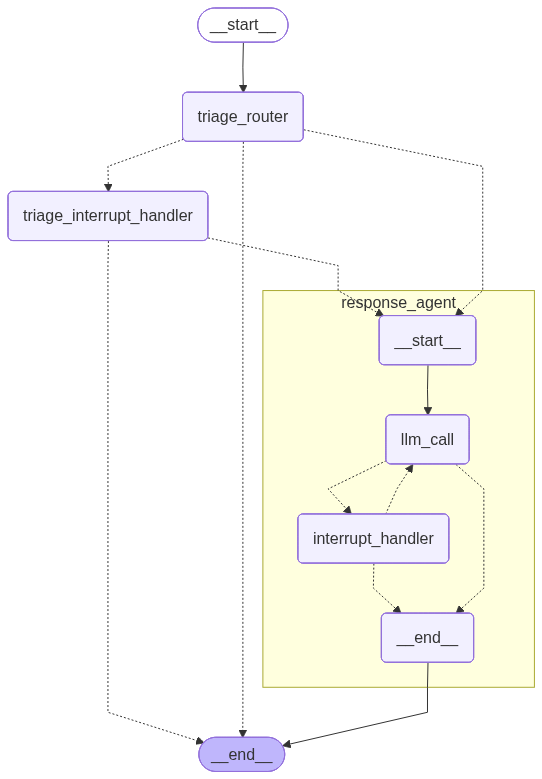

In [9]:
import sys
sys.path.append("../src")

from email_assistant.utils import show_graph
from email_assistant.email_assistant_hitl import triage_router

# Conditional edge function
def should_continue(state: State) -> Literal["interrupt_handler", "__end__"]:
    """Route to tool handler, or end if Done tool called"""
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls: 
            if tool_call["name"] == "Done":
                return END
            else:
                return "interrupt_handler"

# Build workflow
agent_builder = StateGraph(State)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("interrupt_handler", interrupt_handler)

# Add edges
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "interrupt_handler": "interrupt_handler",
        END: END,
    },
)

# Compile the agent
response_agent = agent_builder.compile()

# Build overall workflow
overall_workflow = (
    StateGraph(State, input_schema=StateInput)
    .add_node(triage_router)
    .add_node(triage_interrupt_handler)
    .add_node("response_agent", response_agent)
    .add_edge(START, "triage_router")
    
)

email_assistant = overall_workflow.compile()
show_graph(email_assistant, xray=True)

### 📋 HITL 模式总览

| 触发点 | 系统动作 | 用户能做什么 |
|---------|---------|--------------|
| **Triage Interrupt**(分类为 notify) | 显示邮件给用户 | **Ignore**(结束)/ **Response**(转交 response agent) |
| **`write_email` 调用前** | 显示拟发邮件 | Accept / Edit / Response(反馈) / Ignore |
| **`schedule_meeting` 调用前** | 显示拟订会议 | Accept / Edit / Response / Ignore |
| **`Question` 调用** | 向用户提问 | Response(回答) / Ignore(结束) |

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**💡 设计规律**:**信号型工具**(Question)只能 Response/Ignore;**副作用型工具**(write_email、schedule_meeting)四种都能用 —— 因为副作用需要精确审核。

</div>

### 🧪 ① Interrupts 让你 Review 和 Accept 工具调用

In [10]:
import uuid
from langgraph.checkpoint.memory import InMemorySaver

# Email to respond to
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager",
}

# Compile the graph with checkpointer
checkpointer = InMemorySaver()
graph = overall_workflow.compile(checkpointer=checkpointer)
thread_id_1 = uuid.uuid4()
thread_config_1 = {"configurable": {"thread_id": thread_id_1}}

# Run the graph until a tool call that we choose to interrupt
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_1):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

Running the graph until the first interrupt...
📧 Classification: RESPOND - This email requires a response

INTERRUPT OBJECT:
Action Request: {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com', 'lance@company.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 45, 'preferred_day': '2026-05-19', 'start_time': 14}}


In [ ]:
import sys
sys.path.insert(0, "/Users/bohaoli/Desktop/tuto/tuto_langchain/official/langchain-langgraph-langsmith/utils")

from utils import ppm, ppms, debug
debug(Interrupt_Object.value[0]['action_request'])

╭─────────────────────────────────────────────────── 🧠 Debug ────────────────────────────────────────────────────╮
│ {                                                                                                               │
│   "action": "schedule_meeting",                                                                                 │
│   "args": {                                                                                                     │
│     "attendees": [                                                                                              │
│       "pm@client.com",                                                                                          │
│       "lance@company.com"                                                                                       │
│     ],                                                                                                          │
│     "subject": "Tax Planning Strategies Discussion",                                                            │
│     "duration_minutes": 45,                                                                                     │
│     "preferred_day": "2026-05-19",                                                                              │
│     "start_time": 14                                                                                            │
│   }                                                                                                             │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### 🛑 发生了什么?

我们撞上了 [interrupt](https://langchain-ai.github.io/langgraph/concepts/interrupts/),执行 **暂停在工具调用前**。`action`(工具名)和 `args`(参数)显示给用户。

### ▶️ 怎么处理 interrupt? `Command` 接口登场

[`Command` 对象有几个强大能力](https://langchain-ai.github.io/langgraph/how-tos/command/):

| 用途 | 字段 | 描述 |
|------|------|------|
| 流程控制(node 内返回) | `goto` | 指定下一个节点 |
| 状态更新(node 内返回) | `update` | 修改 state |
| **从 interrupt 续跑** | `resume` | 提供 `interrupt(...)` 的返回值 ⭐ |

我们用 `Command(resume=...)` **续跑暂停的 graph**。

### 📦 Agent Inbox 的 resume 格式

我们的 graph 设计为处理 **一个 list of dicts**,每个 dict 有 `type` 字段,值是 `accept` / `edit` / `ignore` / `response` 之一。

所以 **accept 一个工具调用**,只需传:

```python
Command(resume=[{"type": "accept"}])
```

<div class="dark-orange" style="background:#2d2418; color:#fed7aa; padding:10px 24px; border-left:4px solid #fb923c; border-radius:4px; width:97%;"><style>.dark-orange strong{color:#67e8f9;}</style>

💡 **这个数据结构是 Agent Inbox 的约定**。在 Agent Inbox UI 里点 Accept 按钮 = 后台发了这个 Command。

</div>

In [14]:
from langgraph.types import Command

print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_1):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user accepting the {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com', 'lance@company.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 45, 'preferred_day': '2026-05-19', 'start_time': 14}} tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': 'Hello,\n\nThank you for reaching out. I am available on Tuesday, May 19th at 2:00 PM for a 45-minute call to discuss tax planning strategies. I have scheduled the meeting accordingly.\n\nLooking forward to your suggestions.\n\nBest regards,\nLance'}}


In [15]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_1):
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user accepting the {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': 'Hello,\n\nThank you for reaching out. I am available on Tuesday, May 19th at 2:00 PM for a 45-minute call to discuss tax planning strategies. I have scheduled the meeting accordingly.\n\nLooking forward to your suggestions.\n\nBest regards,\nLance'}} tool call...


In [16]:
state = graph.get_state(thread_config_1)
for m in state.values['messages']:
    m.pretty_print()

================================ Human Message =================================

Respond to the email: 

**Subject**: Tax season let's schedule call
**From**: Project Manager <pm@client.com>
**To**: Lance Martin <lance@company.com>

Lance,

It's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.

Are you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.

Regards,
Project Manager

---

================================== Ai Message ==================================
Tool Calls:
  check_calendar_availability (call_SW4eOZcFSiZSQbwg8r3ilcq1)
 Call ID: call_SW4eOZcFSiZSQbwg8r3ilcq1
  Args:
    day: 2026-05-19
  check_calendar_availability (call_K9cbbxNrgnUbfs6hB2pDnPW2)
 Call ID: call_K9cbbxNrgnUbfs6hB2pDnPW2
  Args:
    day: 2026-05-21
================================= Tool Message =================================

Ava

### ✏️ ② Interrupts 让你 Edit 工具调用

这个测试演示 **编辑** 模式:

| # | 步骤 |
|---|------|
| 1 | 同一封 tax planning 邮件 |
| 2 | agent 提出会议方案(同上次) |
| 3 | **用户编辑** 会议参数:duration 从 45 → 30 分钟,主题改简洁 |
| 4 | agent 写邮件时 **自动适配** 这些变化 |
| 5 | **用户进一步编辑** 邮件:更短、更随意 |
| 6 | 流程完成,**两处修改都生效** |

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**✨ HITL 最强大的能力之一**

用户可以 **在执行前精确修改** agent 的动作,确保最终结果符合自己偏好,**不用自己处理所有细节**(agent 负责草稿,用户负责微调)。

</div>

In [ ]:
# Same email as before
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager",
}

# Compile the graph with new thread
checkpointer = InMemorySaver()
graph = overall_workflow.compile(checkpointer=checkpointer)
thread_id_2 = uuid.uuid4()
thread_config_2 = {"configurable": {"thread_id": thread_id_2}}

# Run the graph until the first interrupt - will be classified as "respond" and the agent will create a write_email tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_2):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

Running the graph until the first interrupt...
📧 Classification: RESPOND - This email requires a response

INTERRUPT OBJECT:
Action Request: {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com', 'lance@company.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 45, 'preferred_day': '2026-05-19', 'start_time': 14}}


### ✏️ 编辑 `schedule_meeting` 工具调用

agent 提出初始会议方案后,模拟用户用 **edit** 功能修改。

| # | 行为 |
|---|------|
| 1 | 用户收到跟上次一样的会议方案 |
| 2 | 不点 accept,改 **参数**:duration 45 → 30 分钟,保持同一天同一时间 |
| 3 | `edit` 回复 **必须包含完整的新参数集**(不是 diff) |
| 4 | interrupt_handler **用新参数替换** 原 tool_call 的 args |
| 5 | 工具 **用编辑后的参数** 执行 |

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**⚠️ Edit 模式必须传完整 args,不是只传变更字段**

LangGraph 的 edit 不是 diff/patch 模式——你要把所有参数原样复制一份,改动你想改的字段,然后整个传回。否则没改的字段会丢失。

</div>

In [18]:
# Now simulate user editing the schedule_meeting tool call
print("\nSimulating user editing the schedule_meeting tool call...")
edited_schedule_args = {
    "attendees": ["pm@client.com", "lance@company.com"],
    "subject": "Tax Planning Discussion",
    "duration_minutes": 30,  # Changed from 45 to 30
    "preferred_day": "2025-05-06",
    "start_time": 14,
}

for chunk in graph.stream(
    Command(resume=[{"type": "edit", "args": {"args": edited_schedule_args}}]), config=thread_config_2
):
    # Inspect response_agent most recent message
    if "response_agent" in chunk:
        chunk["response_agent"]["messages"][-1].pretty_print()
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user editing the schedule_meeting tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': 'Hi,\n\nThank you for reaching out. I appreciate your suggestions regarding tax planning strategies. I am available next week on Tuesday, May 20th at 2:00 PM for a 30-minute call to discuss this further. If you need the full 45 minutes, please let me know and I can adjust accordingly.\n\nLooking forward to our discussion.\n\nBest regards,\nLance'}}


### ✏️ 编辑 `write_email` 工具调用

接受修改后的会议方案后,agent 草拟邮件,反映 30 分钟时长。现在演示 **编辑邮件内容**:

| # | 行为 |
|---|------|
| 1 | agent 的邮件已自适应到 30 分钟时长 |
| 2 | 模拟用户大改邮件:**完全重写为更短更随意** · **改提到的会议日期**(模拟修正 agent 错误) · **改成"请确认"** 而不是"已订" |
| 3 | `edit` 回复包含 **完整新内容** |
| 4 | tool 参数被新内容替换 |
| 5 | 邮件用用户偏好的措辞发出 |

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**💡 HITL 的真正威力 = 复杂沟通任务**

- agent 负责 **结构和初稿**
- 人负责 **微调语气、风格、关键事实**

→ 比 「agent 全做」 或 「人全做」 都高效。这是 ambient agent 的核心价值主张。

</div>

In [19]:
# Now simulate user editing the write_email tool call
print("\nSimulating user editing the write_email tool call...")
edited_email_args = {
    "to": "pm@client.com",
    "subject": "Re: Tax season let's schedule call",
    "content": "Hello Project Manager,\n\nThank you for reaching out about tax planning. I scheduled a 30-minute call next Thursday at 3:00 PM. Would that work for you?\n\nBest regards,\nLance Martin",
}

for chunk in graph.stream(
    Command(resume=[{"type": "edit", "args": {"args": edited_email_args}}]), config=thread_config_2
):
    # Inspect response_agent most recent message
    if "response_agent" in chunk:
        chunk["response_agent"]["messages"][-1].pretty_print()
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user editing the write_email tool call...
================================== Ai Message ==================================
Tool Calls:
  Done (call_fZ1slvZPCYF9mqdHdnf2Jquw)
 Call ID: call_fZ1slvZPCYF9mqdHdnf2Jquw
  Args:
    done: True


完整 message 历史和 trace:

🔗 https://smith.langchain.com/public/21769510-d57a-41e4-b5c7-0ddb23c237d8/r

In [ ]:
state = graph.get_state(thread_config_2)
for m in state.values['messages']:
    m.pretty_print()

### 💬 ③ Interrupts 让你给工具调用 *提供反馈*

这组测试演示 **"response" 模式** —— **不编辑、不接受**,而是给反馈。

### 📋 3 个反馈场景

**1. 会议安排**:
- 用户说"我想 30 分钟而不是 45,而且喜欢下午开会"
- agent 把反馈转化为新提案
- 用户接受

**2. 邮件起草**:
- 用户说"要短一点、不那么正式、加个特定结尾"
- agent 完全重写邮件
- 用户接受

**3. 问题回答**(`Question` 工具):
- agent 不确定时调用 Question
- 用户回答并加上下文
- agent 把答案融进后续动作

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 "Response" 在 accept 和 edit 之间架了座桥**

- **Edit**:你必须 **写完整新参数**,精确控制
- **Response**:你用 **自然语言** 表达偏好,让 agent **重新生成**

特别适合:
- **调语气和风格**(「正式点」「友好点」)
- **补 agent 漏掉的上下文**
- **改变 agent 的思路**(「换个角度」)
- **回答 Question 时塑造后续步骤**

</div>

In [20]:
# Respond - Meeting Request Email
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager"
}

# Compile the graph
checkpointer = InMemorySaver()
graph = overall_workflow.compile(checkpointer=checkpointer)
thread_id_5 = uuid.uuid4()
thread_config_5 = {"configurable": {"thread_id": thread_id_5}}

# Run the graph until the first interrupt 
# Email will be classified as "respond" 
# Agent will create a schedule_meeting and write_email tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_5):
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

Running the graph until the first interrupt...
📧 Classification: RESPOND - This email requires a response

INTERRUPT OBJECT:
Action Request: {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 45, 'preferred_day': '2026-05-19', 'start_time': 14}}


### 💬 给 `schedule_meeting` 提供反馈

| # | 行为 |
|---|------|
| 1 | agent 提议标准 45 分钟会议,周二 14:00 |
| 2 | 我们 **不接受、不编辑**,而是 **用自然语言** 给反馈 |
| 3 | 反馈内容:**「我想 30 分钟,而且偏好下午 14 点之后」** |
| 4 | agent 通过 `response` 类型收到反馈 |
| 5 | interrupt_handler **把反馈作为 ToolMessage** 加进 state |
| 6 | agent **重新生成** 工具调用,自动适应这两个偏好 |

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**💎 Edit vs Response 的对比**

- **Edit**:用户写「duration=30, time=14:30」精确 args
- **Response**:用户写「短一点,下午」自然语言 → **agent 自己理解并应用** 到 args

后者更 **会话式**,但需要 agent 「**正确理解**」反馈 → 容错性 vs 精确性的取舍。

</div>

In [21]:
print(
    f"\nSimulating user providing feedback for the {Interrupt_Object.value[0]['action_request']['action']} tool call..."
)
for chunk in graph.stream(
    Command(
        resume=[
            {
                "type": "response",
                "args": "Please schedule this for 30 minutes instead of 45 minutes, and I prefer afternoon meetings after 2pm.",
            }
        ]
    ),
    config=thread_config_5,
):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user providing feedback for the schedule_meeting tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 30, 'preferred_day': '2026-05-19', 'start_time': 14}}


### ✅ 反馈后,接受修改后的 `schedule_meeting` 工具调用

In [22]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_5):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user accepting the {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 30, 'preferred_day': '2026-05-19', 'start_time': 14}} tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': 'Hello,\n\nThank you for reaching out. I’ve scheduled a 30-minute call for us to discuss tax planning strategies on Tuesday, May 19th at 2:00 PM. Please let me know if this time works for you or if you need to adjust.\n\nLooking forward to your suggestions.\n\nBest regards,\nLance'}}


### 💬 给 `write_email` 提供反馈

接受修改后的会议后,agent 写邮件。我们测 **对邮件内容** 的反馈:

| # | 行为 |
|---|------|
| 1 | agent 写的邮件比较正式、详细 |
| 2 | 我们提 **风格反馈**:**短一点 · 不那么正式 · 加个"期待见面"结尾** |
| 3 | agent 根据反馈 **完全重写** 邮件 |
| 4 | 新草稿短、随意、包含要的结尾 |

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**✨ 自然语言反馈 = 内容创作的杀手锏**

- 用户 **不用自己写整封邮件**(那也太累)
- 只需给 **高层指引**(风格、语气、内容方向)
- agent **基于指引** 实际写
- 结果 **既符合用户偏好,又保留必要信息**

message 历史会显示 **原版和修改版** 两封邮件 → 反馈是如何被纳入的一目了然。

</div>

In [23]:
print(
    f"\nSimulating user providing feedback for the {Interrupt_Object.value[0]['action_request']['action']} tool call..."
)
for chunk in graph.stream(
    Command(
        resume=[
            {
                "type": "response",
                "args": "Shorter and less formal. Include a closing statement about looking forward to the meeting!",
            }
        ]
    ),
    config=thread_config_5,
):
    # Inspect response_agent most recent message
    if "response_agent" in chunk:
        chunk["response_agent"]["messages"][-1].pretty_print()
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user providing feedback for the write_email tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': "Hi,\n\nI've set up a 30-minute call for us on Tuesday, May 19th at 2:00 PM to go over tax planning. Let me know if that works or if you need a different time.\n\nLooking forward to our chat!\n\nThanks,\nLance"}}


### ✅ 反馈后,接受 `write_email`

In [24]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_5):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user accepting the {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': "Hi,\n\nI've set up a 30-minute call for us on Tuesday, May 19th at 2:00 PM to go over tax planning. Let me know if that works or if you need a different time.\n\nLooking forward to our chat!\n\nThanks,\nLance"}} tool call...


完整 message 历史和 trace:

🔗 https://smith.langchain.com/public/57006770-6bb3-4e40-b990-143c373ebe60/r

可以看到 **用户反馈是如何被纳入** tool call 的。

In [ ]:
state = graph.get_state(thread_config_5)
for m in state.values['messages']:
    m.pretty_print()

### ❓ ④ Interrupts 解锁新工具 — `Question`

测试一封邮件,会触发 `Question` 工具(agent 信息不全时调用)。

### 📋 场景:Brunch 邀请

| # | 行为 |
|---|------|
| 1 | 邀请邮件,agent **问** 偏好的日期/时间 |
| 2 | 我们不忽略,而是 **给一个有上下文的回答**:**确认邀请这些人 · 还要看哪个周末方便 · 需要订位** |
| 3 | agent 综合这些信息 **写一封完整邮件**: 包含所有反馈 · 注意到没具体时间 → 建议查日历 · 包含订位细节 |
| 4 | 最终邮件 **同时反映** 原邀请和我们的额外指引 |

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**🎁 Question 工具 = agent 与用户的真正协作**

- Question 让 agent **主动收集** 缺失信息
- 用户回答可以包含 **直接答案 + 额外上下文**
- agent **整合所有信息** 到后续动作
- 最终结果 **反映人机协同智能**(不是单方面 LLM 输出)

</div>

In [25]:
# Respond
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Partner <partner@home.com>",
    "subject": "Dinner?",
    "email_thread": "Hey, do you want italian or indian tonight?",
}

# Compile the graph
checkpointer = InMemorySaver()
graph = overall_workflow.compile(checkpointer=checkpointer)
thread_id_6 = uuid.uuid4()
thread_config_6 = {"configurable": {"thread_id": thread_id_6}}

# Run the graph until the first interrupt
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_6):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

Running the graph until the first interrupt...
📧 Classification: RESPOND - This email requires a response

INTERRUPT OBJECT:
Action Request: {'action': 'Question', 'args': {'content': 'Do you prefer Italian or Indian for dinner tonight? Let me know your choice so I can respond to your partner.'}}


### 💬 给 `Question` 工具调用提供反馈

In [26]:
print(
    f"\nSimulating user providing feedback for the {Interrupt_Object.value[0]['action_request']['action']} tool call..."
)
for chunk in graph.stream(Command(resume=[{"type": "response", "args": "Let's do indian."}]), config=thread_config_6):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user providing feedback for the Question tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'write_email', 'args': {'to': 'partner@home.com', 'subject': 'Dinner?', 'content': 'Indian sounds great for tonight! Looking forward to it.'}}


### ✅ 接受 `write_email` 工具调用

In [27]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_6):
    # Inspect response_agent most recent message
    if 'response_agent' in chunk:
        chunk['response_agent']['messages'][-1].pretty_print()
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user accepting the write_email tool call...
================================== Ai Message ==================================
Tool Calls:
  Done (call_zt0ogwzjnKzcFqEEPGVlS5QR)
 Call ID: call_zt0ogwzjnKzcFqEEPGVlS5QR
  Args:
    done: True


完整 message 历史和 trace:

🔗 https://smith.langchain.com/public/f4c727c3-b1d9-47a5-b3d0-3451619db8a2/r

用户反馈 **被纳入** 邮件回复。

In [28]:
state = graph.get_state(thread_config_6)
for m in state.values['messages']:
    m.pretty_print()

================================ Human Message =================================

Respond to the email: 

**Subject**: Dinner?
**From**: Partner <partner@home.com>
**To**: Lance Martin <lance@company.com>

Hey, do you want italian or indian tonight?

---

================================== Ai Message ==================================
Tool Calls:
  Question (call_qLo9yZEYJyWkvyJfrFJ7FEm5)
 Call ID: call_qLo9yZEYJyWkvyJfrFJ7FEm5
  Args:
    content: Do you prefer Italian or Indian for dinner tonight? Let me know your choice so I can respond to your partner.
================================= Tool Message =================================

User answered the question, which can we can use for any follow up actions. Feedback: Let's do indian.
================================== Ai Message ==================================
Tool Calls:
  write_email (call_bKWRaMdHp8H2NhXvgxqGqB4c)
 Call ID: call_bKWRaMdHp8H2NhXvgxqGqB4c
  Args:
    to: partner@home.com
    subject: Dinner?
    content: Indian

## 🚀 部署

本地部署一个带 HITL 的 email assistant(源码 `src/email_assistant/email_assistant_hitl.py`):

```bash
langgraph dev
```

在 Studio 里选 **`email_assistant_hitl`**,提交下面这封邮件:

<div class="dark-orange" style="background:#2d2418; color:#fed7aa; padding:10px 24px; border-left:4px solid #fb923c; border-radius:4px; width:97%;"><style>.dark-orange strong{color:#67e8f9;}</style>

💡 **别忘了**:`langgraph dev` 必须在 `langgraph.json` 所在目录跑(即 `project-002-ambiant-agents/`)。

</div>

In [ ]:
{
  "author": "Alice Smith <alice.smith@company.com>",
  "to": "John Doe <john.doe@company.com>",
  "subject": "Quick question about API documentation",
  "email_thread": "Hi John,\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\nThanks!\nAlice"
}

### 🗄️ 服务器架构

我们的 server 是 **stateless**(无状态)。

| 部署模式 | thread 存哪 |
|---------|-------------|
| **本地** | 项目下的 `.langgraph_api` 文件夹 |
| **[Hosted](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options)** | Postgres |

### 🛑 Interrupted Threads

被中断的 thread 状态 = `interrupted`,在 Studio 里能看到:

![studio-img](img/studio-interrupt.png)

### 📮 Agent Inbox — 自定义 UI

我们用一个自定义界面来查看 interrupted threads:[**Agent Inbox**](https://dev.agentinbox.ai/)。

这个界面方便地 **edit / approve / ignore / 提供 feedback**。

### 🔌 接入步骤

在 [dev.agentinbox.ai](https://dev.agentinbox.ai/) 添加你的图:

| 字段 | 值 |
|------|----|
| Graph name | `langgraph.json` 里的名字(`email_assistant_hitl`) |
| Graph URL | `http://127.0.0.1:2024/` |

所有 interrupted threads 就显示在那里:

![agent-inbox-img](img/agent-inbox.png)

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🔑 Agent Inbox 本质 = `Command(resume=...)` 的可视化封装**

它就是个 UI 包装,底层做的事跟我们之前用 SDK [发 `Command` 续跑](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/wait-user-input/#interacting-with-the-agent) 一模一样。**用户点的按钮 = 一个 Command 对象发回 graph**。

</div>

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

## ✨ 本节带走

**HITL 核心 = 在敏感动作前暂停,接收用户的 4 种回复**:

| 用户操作 | 适用 | 实现 |
|---------|------|------|
| **Accept** | 同意 → 原参数执行 | `{"type": "accept"}` |
| **Edit** | 改参数 → 用新参数执行 | `{"type": "edit", "args": {...}}` |
| **Response** | 自然语言反馈 → agent 重生成 | `{"type": "response", "args": "..."}` |
| **Ignore** | 取消 → END | `{"type": "ignore"}` |

🎯 **关键技术细节**:

1. `interrupt(payload)` + `Command(resume=...)` 是 HITL 的物理基础
2. **payload 的结构 = Agent Inbox 渲染什么**(action_request / config / description)
3. Edit 需要 **完整新参数**(不是 diff)
4. Response 让 agent **重新生成**,适合 **风格 / 上下文** 类反馈
5. `Question` 工具是 HITL 解锁的新能力:agent 主动问用户

</div>